# 💳 Loan Default Risk Prediction

## Problem
Predict whether a customer will default on a loan using financial and behavioral data.

Goal:
- Handle imbalanced data
- Build accurate model
- Optimize business decision (threshold)
- Explain model using SHAP

In [2]:
# =========================
# IMPORT LIBRARIES
# =========================

import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

from xgboost import XGBClassifier

import shap
import joblib
import optuna

c:\Users\sayan\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# =========================
# INSTALL REQUIRED PACKAGES
# =========================

!pip install pandas numpy scikit-learn xgboost shap optuna joblib streamlit

In [3]:
# =========================
# LOAD DATA
# =========================

from src.data_loader import load_data

app, bureau, prev, inst = load_data()

print(app.shape, bureau.shape, prev.shape, inst.shape)

(307511, 122) (1716428, 17) (1670214, 37) (13605401, 8)


In [4]:
# =========================
# FEATURE ENGINEERING
# =========================

# -------- BUREAU --------
bureau["DEBT_RATIO"] = bureau["AMT_CREDIT_SUM_DEBT"] / (bureau["AMT_CREDIT_SUM"] + 1)
bureau["HAS_OVERDUE"] = (bureau["AMT_CREDIT_SUM_OVERDUE"] > 0).astype(int)

bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "SK_ID_BUREAU": "count",
    "AMT_CREDIT_SUM": ["mean", "sum"],
    "DEBT_RATIO": "mean",
    "HAS_OVERDUE": "max"
})

bureau_agg.columns = ["_".join(col) for col in bureau_agg.columns]
bureau_agg = bureau_agg.reset_index()

# -------- PREVIOUS --------
prev_agg = prev.groupby("SK_ID_CURR").agg({
    "SK_ID_PREV": "count",
    "AMT_APPLICATION": "mean",
    "AMT_CREDIT": "mean"
}).reset_index()

# -------- INSTALLMENTS --------
inst_merged = inst.merge(
    prev[["SK_ID_PREV", "SK_ID_CURR"]],
    on="SK_ID_PREV",
    how="left"
)

if "SK_ID_CURR_y" in inst_merged.columns:
    inst_merged["SK_ID_CURR"] = inst_merged["SK_ID_CURR_y"]

inst_merged["LATE_PAYMENT"] = (
    inst_merged["DAYS_ENTRY_PAYMENT"] > inst_merged["DAYS_INSTALMENT"]
).astype(int)

inst_merged["PAYMENT_DELAY"] = (
    inst_merged["DAYS_ENTRY_PAYMENT"] - inst_merged["DAYS_INSTALMENT"]
)

inst_merged["PAYMENT_RATIO"] = (
    inst_merged["AMT_PAYMENT"] / (inst_merged["AMT_INSTALMENT"] + 1)
)

inst_agg = inst_merged.groupby("SK_ID_CURR").agg({
    "LATE_PAYMENT": "mean",
    "PAYMENT_DELAY": "mean",
    "PAYMENT_RATIO": "mean"
}).reset_index()

# -------- MERGE --------
df = app.copy()

df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
df = df.merge(prev_agg, on="SK_ID_CURR", how="left")
df = df.merge(inst_agg, on="SK_ID_CURR", how="left")

df = df.fillna(-999)

print("Final shape:", df.shape)

Final shape: (307511, 133)


In [5]:
# =========================
# CLASS IMBALANCE
# =========================

df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [6]:
# =========================
# TRAIN-TEST SPLIT
# =========================

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
# =========================
# ENCODE CATEGORICALS
# =========================

cat_cols = X_train.select_dtypes(include=["object", "string"]).columns

X_train = X_train.copy()
X_val = X_val.copy()

X_train[cat_cols] = X_train[cat_cols].astype(str)
X_val[cat_cols] = X_val[cat_cols].astype(str)

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_val[cat_cols] = encoder.transform(X_val[cat_cols])

In [8]:
if "SK_ID_CURR" in X_train.columns:
    X_train = X_train.drop(columns=["SK_ID_CURR"])
    X_val = X_val.drop(columns=["SK_ID_CURR"])

In [9]:
# =========================
# OPTUNA TUNING
# =========================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_int("scale_pos_weight", 5, 15),
        "eval_metric": "auc",
        "n_jobs": -1,
        "random_state": 42
    }

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    preds = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print(study.best_params)

[I 2026-04-29 00:42:32,878] A new study created in memory with name: no-name-e60a1ce8-c41f-4795-9943-294416594f29
[I 2026-04-29 00:42:37,089] Trial 0 finished with value: 0.7541659403863409 and parameters: {'n_estimators': 190, 'max_depth': 3, 'learning_rate': 0.03226711518865406, 'subsample': 0.7482383613940929, 'colsample_bytree': 0.6343104775448414, 'scale_pos_weight': 13}. Best is trial 0 with value: 0.7541659403863409.
[I 2026-04-29 00:42:42,168] Trial 1 finished with value: 0.7703741269006146 and parameters: {'n_estimators': 283, 'max_depth': 4, 'learning_rate': 0.11249735151192068, 'subsample': 0.6536033927454367, 'colsample_bytree': 0.7883683459450044, 'scale_pos_weight': 7}. Best is trial 1 with value: 0.7703741269006146.
[I 2026-04-29 00:42:50,215] Trial 2 finished with value: 0.7721970842841773 and parameters: {'n_estimators': 490, 'max_depth': 4, 'learning_rate': 0.07857318794218486, 'subsample': 0.7840507490116857, 'colsample_bytree': 0.6697154811705759, 'scale_pos_weight'

{'n_estimators': 490, 'max_depth': 4, 'learning_rate': 0.07857318794218486, 'subsample': 0.7840507490116857, 'colsample_bytree': 0.6697154811705759, 'scale_pos_weight': 6}


In [10]:
# =========================
# FINAL MODEL
# =========================

model = XGBClassifier(**study.best_params)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-logloss:0.47582
[100]	validation_0-logloss:0.40434
[200]	validation_0-logloss:0.39772
[300]	validation_0-logloss:0.39447
[400]	validation_0-logloss:0.39132
[489]	validation_0-logloss:0.38950


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6697154811705759
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegres

In [11]:
# =========================
# EVALUATION
# =========================

y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba))
print(classification_report(y_val, y_pred))

ROC-AUC: 0.7717643476745154
              precision    recall  f1-score   support

           0       0.95      0.88      0.91     56538
           1       0.25      0.45      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.67      0.62     61503
weighted avg       0.89      0.85      0.87     61503



In [12]:
# =========================
# THRESHOLD TUNING
# =========================

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred = (y_pred_proba > t).astype(int)

    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    print(f"{t:.2f} | P:{precision:.3f} R:{recall:.3f} F1:{f1:.3f}")

0.10 | P:0.094 R:0.973 F1:0.172
0.15 | P:0.107 R:0.930 F1:0.193
0.20 | P:0.123 R:0.880 F1:0.216
0.25 | P:0.141 R:0.818 F1:0.240
0.30 | P:0.159 R:0.750 F1:0.262
0.35 | P:0.179 R:0.681 F1:0.284
0.40 | P:0.200 R:0.602 F1:0.300
0.45 | P:0.225 R:0.525 F1:0.315
0.50 | P:0.250 R:0.449 F1:0.321
0.55 | P:0.278 R:0.375 F1:0.319
0.60 | P:0.312 R:0.306 F1:0.309
0.65 | P:0.347 R:0.235 F1:0.281
0.70 | P:0.385 R:0.171 F1:0.236
0.75 | P:0.437 R:0.111 F1:0.177
0.80 | P:0.513 R:0.064 F1:0.113
0.85 | P:0.620 R:0.029 F1:0.055


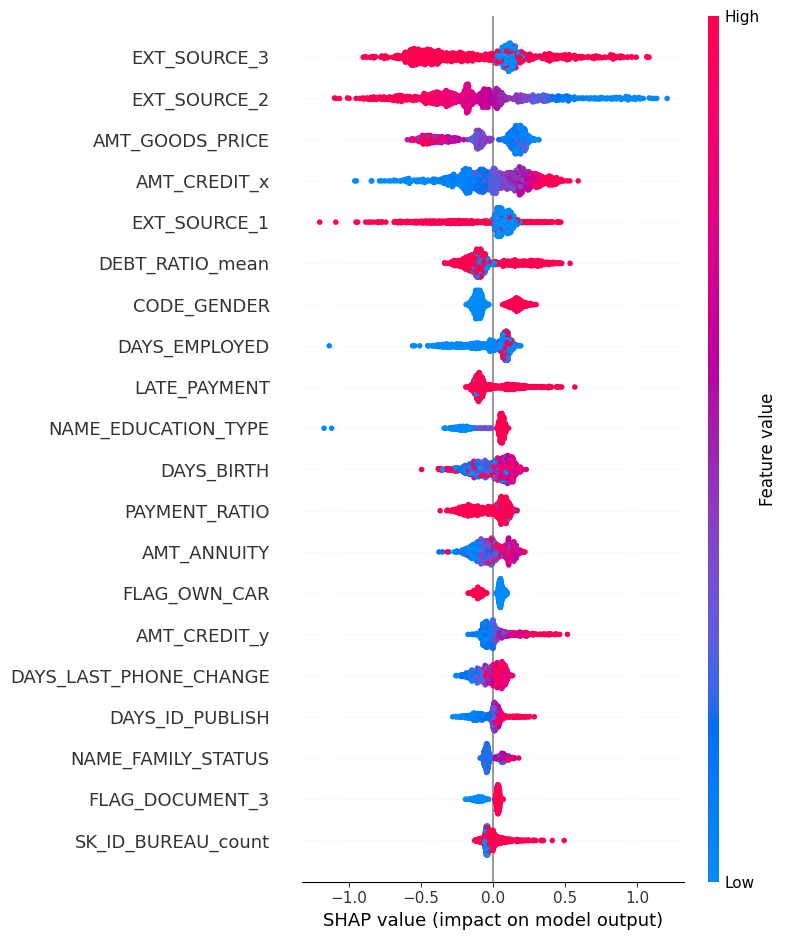

In [13]:
# =========================
# SHAP EXPLAINABILITY
# =========================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values[:1000], X_val[:1000])

In [14]:
# =========================
# SAVE MODEL
# =========================

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/xgb_model.pkl")

print("Model saved!")

Model saved!
